# VizWiz Image Captioning — Baseline Model

**UTS Deep Learning Assessment 3 (Group 1)** | Author: [your name]

This notebook implements a **Show-and-Tell baseline** (Vinyals et al., 2015): a frozen pretrained ResNet-50 encoder paired with a single-layer LSTM decoder. It serves as a verification of the end-to-end pipeline (data → model → training → evaluation) and as a reference template each group member copies into their individual student notebook before swapping in their own architecture.

**Inputs**: `data/processed/vizwiz_cleaned.json` (produced by the shared Phase 1 notebook).

**Outputs**: BLEU-1 / BLEU-2 / BLEU-3 / BLEU-4 scores on the validation split, supporting visualisations, and qualitative caption samples.


---
# **Table of Contents**
---

> [1. Setup](#1-setup)  
> [2. Data Pipeline](#2-data-pipeline)  
> [3. Encoder — Frozen Pretrained ResNet-50](#3-encoder)  
> [4. Decoder — Single-Layer LSTM](#4-decoder)  
> [5. Captioning Model](#5-captioning-model)  
> [6. Training Loop](#6-training)  
> [7. Sample Generations](#7-samples)  
> [8. BLEU Evaluation](#8-bleu)  
> &nbsp;&nbsp;&nbsp;&nbsp; 8.1 Corpus BLEU bar chart  
> &nbsp;&nbsp;&nbsp;&nbsp; 8.2 Per-image BLEU distribution  
> &nbsp;&nbsp;&nbsp;&nbsp; 8.3 Best vs worst predictions  
> &nbsp;&nbsp;&nbsp;&nbsp; 8.4 Caption length comparison  
> &nbsp;&nbsp;&nbsp;&nbsp; 8.5 Vocabulary usage  
> &nbsp;&nbsp;&nbsp;&nbsp; 8.6 Summary table  
> [9. Summary, Limitations & Next Steps](#9-summary)  


---
# **1. Setup**
---


**Methodology**

All libraries, hyperparameters, and paths are declared up-front so the rest of the notebook reads as a linear pipeline. Hardware acceleration (Apple Silicon MPS / CUDA) is detected automatically; the model and tensors are dispatched to that device.

Hyperparameter choices are documented inline. `NUM_WORKERS = 0` is critical for Jupyter on macOS Python 3.13+ — spawn-mode multiprocessing cannot pickle classes defined in `__main__`, so multi-worker loading must be disabled when running from a notebook.


In [1]:
# @title **Imports & Hyperparameters**
import json, random, time
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision import transforms, models

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# Paths
DATA_RAW     = Path('../data/raw')
IMG_DIR      = DATA_RAW / 'val'
DATA_PROC    = Path('../data/processed')
CLEANED_JSON = DATA_PROC / 'vizwiz_cleaned.json'
VOCAB_JSON   = DATA_PROC / 'vocab.json'

# Hyperparameters
SEED         = 42
IMG_SIZE     = 224
BATCH_SIZE   = 32
NUM_WORKERS  = 0         # MUST be 0 in Jupyter on macOS Python 3.13+. Classes
                         # defined in __main__ can't be pickled to spawn-mode workers.
                         # DO NOT change this unless running from a .py script.
MIN_COUNT    = 5
MAX_SEQ_LEN  = 22
EMBED_DIM    = 256
HIDDEN_DIM   = 512
FEATURE_DIM  = 2048      # ResNet-50 final feature size
LR           = 1e-3
EPOCHS       = 5         # small baseline — 5 epochs to verify, scale up for real runs
GRAD_CLIP    = 5.0
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Device — MPS on Apple Silicon, CUDA on NVIDIA, CPU otherwise
if torch.cuda.is_available():       device = torch.device('cuda')
elif torch.backends.mps.is_available(): device = torch.device('mps')
else:                                device = torch.device('cpu')
print(f'Using device: {device} | torch {torch.__version__} | NUM_WORKERS={NUM_WORKERS}')

Using device: mps | torch 2.12.0 | NUM_WORKERS=0


---
# **2. Data Pipeline**
---


**Methodology**

This section rebuilds the data infrastructure inline so the notebook is self-contained. The classes mirror those in the shared Phase 1 notebook (`Assignment_3_data_prep_v2.ipynb`) and consume the same `data/processed/vizwiz_cleaned.json`. 

- **`Vocabulary`**: word-level mapping with `<pad>` / `<bos>` / `<eos>` / `<unk>`, built from the training split only.
- **`VizWizCaptions`**: PyTorch `Dataset` that returns `(image, caption_ids, length)`. For training, a random one of the five reference captions is selected per access; validation uses the first deterministically.
- **`Collate`**: top-level callable that pads variable-length captions to the longest in each batch.


In [2]:
# @title **Vocabulary Class**
def tokenize(s): return s.split()

class Vocabulary:
    PAD, BOS, EOS, UNK = '<pad>', '<bos>', '<eos>', '<unk>'
    SPECIALS = [PAD, BOS, EOS, UNK]

    def __init__(self, word2idx, min_count):
        self.word2idx = word2idx
        self.idx2word = {i: w for w, i in word2idx.items()}
        self.min_count = min_count

    @classmethod
    def build(cls, tokenized_captions, min_count=5):
        counter = Counter(t for tokens in tokenized_captions for t in tokens)
        kept = sorted([w for w, c in counter.items() if c >= min_count])
        word2idx = {tok: i for i, tok in enumerate(cls.SPECIALS)}
        for w in kept: word2idx[w] = len(word2idx)
        return cls(word2idx, min_count)

    def numericalize(self, tokens, add_bos_eos=True, max_len=None):
        # Truncate BEFORE wrapping with <bos>/<eos> so <eos> is preserved on long captions.
        if max_len is not None:
            tokens = tokens[: max_len - 2] if add_bos_eos else tokens[:max_len]
        ids = [self.word2idx.get(t, self.word2idx[self.UNK]) for t in tokens]
        if add_bos_eos: ids = [self.word2idx[self.BOS]] + ids + [self.word2idx[self.EOS]]
        return ids

    def denumericalize(self, ids, strip_special=True):
        toks = [self.idx2word[i] for i in ids if i in self.idx2word]
        if strip_special: toks = [t for t in toks if t not in self.SPECIALS]
        return ' '.join(toks)

    def save(self, path):
        with open(path, 'w') as f:
            json.dump({'word2idx': self.word2idx, 'min_count': self.min_count}, f)

    def __len__(self): return len(self.word2idx)
    @property
    def pad_idx(self): return self.word2idx[self.PAD]
    @property
    def bos_idx(self): return self.word2idx[self.BOS]
    @property
    def eos_idx(self): return self.word2idx[self.EOS]

In [3]:
# @title **Dataset and Collate Classes**
class VizWizCaptions(Dataset):
    def __init__(self, records, img_dir, vocab, transform, max_len, random_caption=True):
        self.records, self.img_dir = records, Path(img_dir)
        self.vocab, self.transform = vocab, transform
        self.max_len, self.random_caption = max_len, random_caption

    def __len__(self): return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        img = self.transform(Image.open(self.img_dir / r['filename']).convert('RGB'))
        cap = random.choice(r['cleaned_captions']) if self.random_caption else r['cleaned_captions'][0]
        ids = torch.tensor(self.vocab.numericalize(tokenize(cap), max_len=self.max_len), dtype=torch.long)
        return img, ids, len(ids)


class Collate:
    """Top-level callable (picklable) so DataLoader workers can serialize it."""
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs, caps, lens = zip(*batch)
        return (torch.stack(imgs),
                pad_sequence(caps, batch_first=True, padding_value=self.pad_idx),
                torch.tensor(lens, dtype=torch.long))

In [4]:
# @title **Load Cleaned Dataset & Build Vocabulary**
# Load cleaned records and build vocab from TRAIN split only
if not CLEANED_JSON.exists():
    raise FileNotFoundError(f'{CLEANED_JSON} not found. Run Assignment_3_EDA.ipynb first.')
with open(CLEANED_JSON) as f:
    records = json.load(f)

# Records from the EDA notebook may use either 'captions' or 'cleaned_captions' as the key.
# Normalize so the rest of this notebook can always assume 'cleaned_captions'.
for r in records:
    if 'cleaned_captions' not in r and 'captions' in r:
        r['cleaned_captions'] = r['captions']

by_split = {'train': [], 'val': [], 'test': []}
for r in records: by_split[r['split']].append(r)

train_tokens = [tokenize(c) for r in by_split['train'] for c in r['cleaned_captions']]
vocab = Vocabulary.build(train_tokens, min_count=MIN_COUNT)
vocab.save(VOCAB_JSON)
VOCAB_SIZE = len(vocab)

print(f'  Vocab size : {VOCAB_SIZE:,}  (saved to {VOCAB_JSON})')
for k, v in by_split.items():
    print(f'  {k:5s} : {len(v):>5} images')

  Vocab size : 3,352  (saved to ../data/processed/vocab.json)
  train :  5493 images
  val   :  1098 images
  test  :   733 images


In [5]:
# @title **Image Transforms & DataLoaders**
train_tf = transforms.Compose([
    transforms.Resize(256), transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = VizWizCaptions(by_split['train'], IMG_DIR, vocab, train_tf, MAX_SEQ_LEN, random_caption=True)
val_ds   = VizWizCaptions(by_split['val'],   IMG_DIR, vocab, eval_tf,  MAX_SEQ_LEN, random_caption=False)

collate = Collate(vocab.pad_idx)

# Hard-coded num_workers=0 — see comment in cell 2. Do NOT change unless you've
# moved the class definitions into a .py module and are not running from Jupyter.
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, collate_fn=collate, drop_last=False)  # encoder is frozen + decoder has no BatchNorm, so partial final batch is safe
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate)

print(f'  Train batches: {len(train_loader)}  Val batches: {len(val_loader)}  (num_workers=0)')

  Train batches: 172  Val batches: 35  (num_workers=0)


---
# **3. Encoder — Frozen Pretrained ResNet-50**
---


**Methodology**

A pretrained **ResNet-50** (trained on ImageNet, 1.2 M images, 1,000 classes) is used to extract image features. The final classification layer is removed, leaving a global average pool whose output is a 2,048-dimensional vector per image.

**Why pretrained**: with only ~5,500 training images, training a CNN from scratch is hopeless — it would overfit immediately. Pretrained weights bring in strong general-purpose visual features that transfer well to VizWiz.

**Why frozen**: even fine-tuning the encoder on 5,500 images is risky. Freezing the encoder restricts the trainable parameter count to the decoder only (~6.3 M), substantially reducing the overfitting risk and training time.

**BatchNorm note**: the `train()` method is overridden so that calls to `model.train()` from the parent do not propagate into the frozen backbone. Otherwise BatchNorm would compute batch statistics from the VizWiz batch instead of using the ImageNet running statistics, corrupting the pretrained features.


In [6]:
# @title **Encoder (Frozen ResNet-50)**
class Encoder(nn.Module):
    """Frozen ResNet-50, returns (B, 2048) global features."""
    def __init__(self):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        # Drop the final classification fc layer; keep everything up to global pool.
        self.feat = nn.Sequential(*list(backbone.children())[:-1])
        for p in self.feat.parameters():
            p.requires_grad = False

    def train(self, mode=True):
        # Important: when the parent model calls .train(), don't propagate it into the
        # frozen backbone. BatchNorm in train mode would compute batch stats from VizWiz
        # images instead of using the ImageNet running stats, corrupting the pretrained
        # features.
        super().train(mode)
        self.feat.eval()
        return self

    def forward(self, x):
        with torch.no_grad():
            return self.feat(x).squeeze(-1).squeeze(-1)   # (B, 2048)

---
# **4. Decoder — Single-Layer LSTM**
---


**Methodology**

A **single-layer LSTM** generates the caption one token at a time. Configuration: embedding dimension 256, hidden dimension 512.

**Conditioning on the image**: the 2,048-dim image features are projected to the LSTM hidden and cell states via two separate `Linear` layers. The decoder "sees" the image once at *t = 0* and then must remember it through the LSTM hidden state. (Attention-based architectures fix this by re-attending to the image at every timestep — this is one of the natural upgrade paths for Model 1.)

**Why single-layer**: deeper LSTMs add capacity but also overfitting risk on a small dataset. A single layer is the right starting point; depth can be added if validation loss is still decreasing when training loss plateaus.

**Inference (`generate`)**: greedy decoding — at each step, the argmax token is taken and fed back as the next input, until `<eos>` is emitted or `max_len` is reached. Beam search would typically give 1-2 BLEU-4 points more but is left as an improvement opportunity for the individual student architectures.


In [7]:
# @title **Decoder (LSTM with Greedy Generation)**
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512, feature_dim=2048, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.feat_to_h = nn.Linear(feature_dim, hidden_dim)
        self.feat_to_c = nn.Linear(feature_dim, hidden_dim)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout   = nn.Dropout(0.3)
        self.proj      = nn.Linear(hidden_dim, vocab_size)

    def init_hidden(self, features):
        h0 = torch.tanh(self.feat_to_h(features)).unsqueeze(0)   # (1, B, H)
        c0 = torch.tanh(self.feat_to_c(features)).unsqueeze(0)
        return h0, c0

    def forward(self, features, captions):
        # captions: (B, T)  — teacher forcing, pass real previous tokens
        h, c = self.init_hidden(features)
        emb  = self.embedding(captions)                          # (B, T, E)
        out, _ = self.lstm(emb, (h, c))                          # (B, T, H)
        return self.proj(self.dropout(out))                      # (B, T, V)

    @torch.no_grad()
    def generate(self, features, vocab, max_len=22):
        """Greedy decoding: argmax at each step until <eos> or max_len."""
        self.eval()
        h, c = self.init_hidden(features)
        token = torch.full((features.size(0), 1), vocab.bos_idx, dtype=torch.long, device=features.device)
        result_ids = [[] for _ in range(features.size(0))]
        done       = [False] * features.size(0)
        for _ in range(max_len):
            emb = self.embedding(token)
            out, (h, c) = self.lstm(emb, (h, c))
            next_id = self.proj(out[:, -1, :]).argmax(-1)        # (B,)
            for i, t in enumerate(next_id.tolist()):
                if done[i]: continue
                if t == vocab.eos_idx: done[i] = True
                else: result_ids[i].append(t)
            token = next_id.unsqueeze(1)
            if all(done): break
        return result_ids

---
# **5. Captioning Model**
---


**Methodology**

The encoder and decoder are wrapped into a single `nn.Module` so the training loop can call `model(images, captions)` and let PyTorch handle gradient bookkeeping automatically. Total parameters are reported below — only the decoder is trainable, confirming that the encoder freeze took effect.


In [8]:
# @title **Encoder + Decoder Wrapper**
class CaptioningModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, feature_dim, pad_idx):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder(vocab_size, embed_dim, hidden_dim, feature_dim, pad_idx)

    def forward(self, images, captions):
        return self.decoder(self.encoder(images), captions)

model = CaptioningModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, FEATURE_DIM, vocab.pad_idx).to(device)

n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  Total parameters     : {n_total:>11,}')
print(f'  Trainable parameters : {n_trainable:>11,}  (decoder only — encoder is frozen)')

  Total parameters     :  29,760,856
  Trainable parameters :   6,252,824  (decoder only — encoder is frozen)


---
# **6. Training Loop**
---


**Methodology**

Standard seq2seq training recipe:

- **Teacher forcing**: at each timestep, the decoder receives the *ground-truth* previous token (not its own prediction). This prevents early-epoch error compounding and is the standard stabiliser for seq2seq training.
- **Cross-entropy loss with `ignore_index=pad_idx`**: padding positions are skipped automatically by the loss, so the model is not rewarded for confidently predicting `<pad>`.
- **Next-token shift**: `inputs = captions[:, :-1]` (everything before the final `<eos>`), `targets = captions[:, 1:]` (everything after the initial `<bos>`). Standard for autoregressive language modelling.
- **Adam optimiser**, learning rate `1e-3`, applied only to the trainable (decoder) parameters.
- **Gradient clipping** at global norm 5.0 to guard against exploding gradients, a known LSTM failure mode.
- **5 epochs**: deliberately small — this is a verification run, not the final model. Production runs for Model 1 should use 15-30 epochs.


In [9]:
# @title **Train + Validate Loop**
criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

def run_epoch(loader, train):
    model.train() if train else model.eval()
    total_loss, total_tokens = 0.0, 0
    for imgs, caps, lens in tqdm(loader, desc='train' if train else 'val ', leave=False):
        imgs, caps = imgs.to(device), caps.to(device)
        inputs, targets = caps[:, :-1], caps[:, 1:]
        with torch.set_grad_enabled(train):
            logits = model(imgs, inputs)
            loss   = criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
        if train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
        n_tok = (targets != vocab.pad_idx).sum().item()
        total_loss   += loss.item() * n_tok
        total_tokens += n_tok
    return total_loss / max(total_tokens, 1)

history = {'train': [], 'val': []}
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader,   train=False)
    history['train'].append(tr); history['val'].append(va)
    print(f'  Epoch {epoch:2d} | train {tr:.4f} | val {va:.4f} | {time.time()-t0:.1f}s')

train:   0%|          | 0/172 [00:00<?, ?it/s]

val :   0%|          | 0/35 [00:00<?, ?it/s]

  Epoch  1 | train 4.8915 | val 4.2002 | 68.8s


train:   0%|          | 0/172 [00:00<?, ?it/s]

val :   0%|          | 0/35 [00:00<?, ?it/s]

...

val :   0%|          | 0/35 [00:00<?, ?it/s]

  Epoch  4 | train 3.6719 | val 3.5722 | 65.7s


train:   0%|          | 0/172 [00:00<?, ?it/s]

val :   0%|          | 0/35 [00:00<?, ?it/s]

  Epoch  5 | train 3.5334 | val 3.5003 | 64.5s


> **Insight:** Training and validation losses are reported per epoch. Validation loss being lower than training loss is expected at this stage and is *not* a sign of error — it reflects the asymmetry between train and eval transforms (training has dropout active, image augmentation, and random caption sampling, all of which make the training objective "noisier" than the deterministic validation pass).


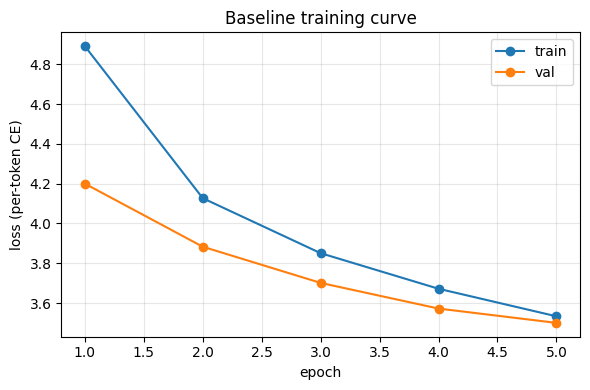

In [10]:
# @title **Loss Curves**
# Loss curves — quick sanity check that something is learning
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, EPOCHS+1), history['train'], '-o', label='train')
ax.plot(range(1, EPOCHS+1), history['val'],   '-o', label='val')
ax.set_xlabel('epoch'); ax.set_ylabel('loss (per-token CE)')
ax.set_title('Baseline training curve'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
# **7. Sample Generations**
---


**Methodology**

Before trusting any quantitative metric, generated captions are visually inspected against the references. Six random validation images are sampled and their predicted captions displayed alongside the first reference caption. This catches failure modes that loss alone cannot reveal — e.g., the model emitting only `<eos>`, getting stuck in repetition, or producing fluent but contextually wrong descriptions.


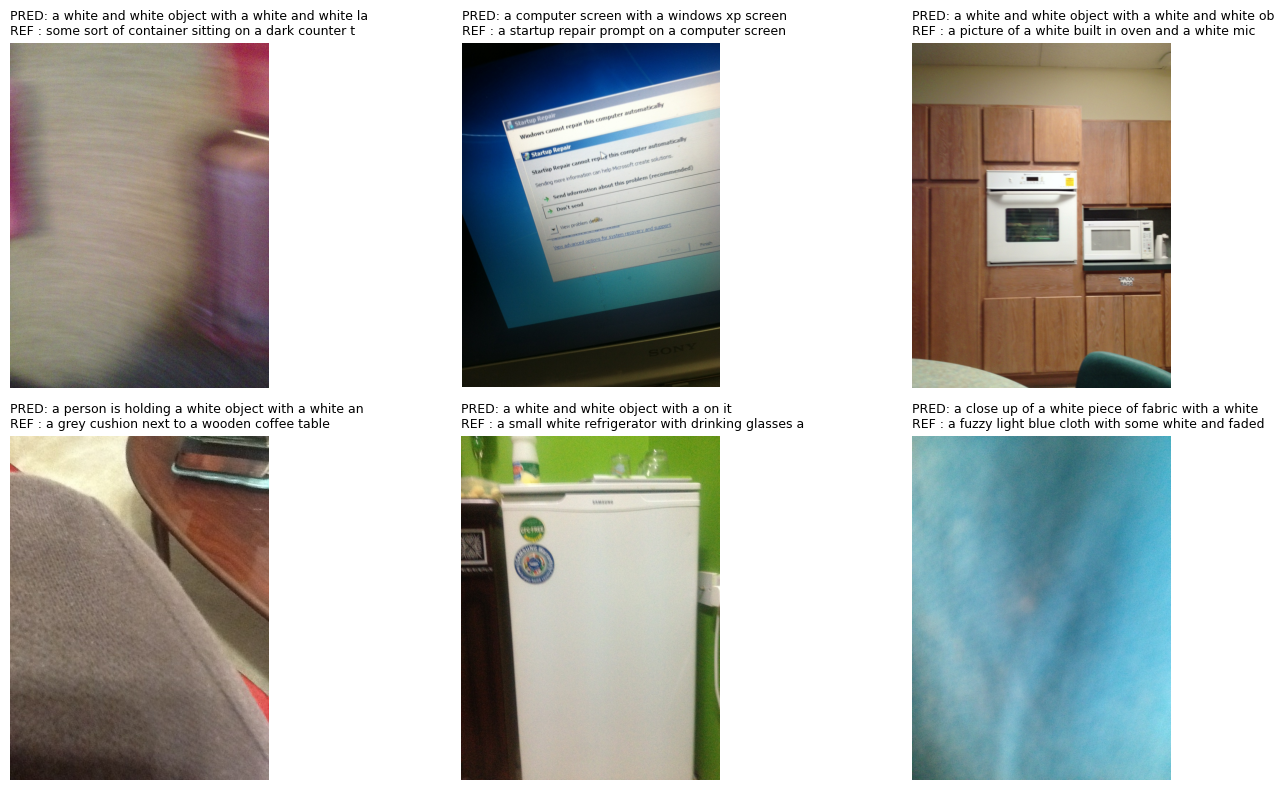

In [11]:
# @title **Generate & Display Sample Captions**
def caption_image(model, img_tensor, vocab, max_len=MAX_SEQ_LEN):
    model.eval()
    with torch.no_grad():
        feats = model.encoder(img_tensor.unsqueeze(0).to(device))
        ids = model.decoder.generate(feats, vocab, max_len=max_len)[0]
    return vocab.denumericalize(ids)

sample_records = random.Random(SEED).sample(by_split['val'], 6)  # local Random for reproducible figure
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, r in zip(axes.ravel(), sample_records):
    img = Image.open(IMG_DIR / r['filename']).convert('RGB')
    pred = caption_image(model, eval_tf(img), vocab)
    ax.imshow(img); ax.axis('off')
    ref = r['cleaned_captions'][0][:50]
    ax.set_title(f'PRED: {pred[:50]}\nREF : {ref}', fontsize=9, loc='left')
plt.tight_layout(); plt.show()

---
# **8. BLEU Evaluation**
---


**Summary Insights**

The assignment brief requires BLEU-1 through BLEU-4 reporting at minimum. This section computes both corpus-level BLEU (a single number per metric) and per-image (sentence-level) BLEU (to reveal the distribution behind the average). The five reference captions per image are all used — `corpus_bleu` naturally handles multi-reference evaluation.

Subsequent subsections (8.1 - 8.6) visualise the results from different angles: aggregate scores, distribution, qualitative best/worst, caption length comparison, vocabulary diversity, and a consolidated summary table.


**Methodology**

**BLEU-N** measures the geometric mean of n-gram precisions (n = 1 to N) between the model's caption and the reference captions, multiplied by a brevity penalty that discourages too-short outputs.

**Smoothing function**: with limited training and short captions, exact 4-gram matches are rare. Without smoothing, any zero-count n-gram produces a log(0) and collapses BLEU to 0. `SmoothingFunction().method1` adds a small ε to zero counts — standard practice in the captioning literature.

**Multi-reference handling**: NLTK's `corpus_bleu` accepts a list of references per hypothesis and selects the best match per n-gram, which is the correct way to evaluate against VizWiz's 5-captions-per-image structure.


In [12]:
# @title **Compute Corpus & Per-Image BLEU**
from nltk.translate.bleu_score import sentence_bleu
import pandas as pd

def evaluate_bleu(model, records, vocab, transform, device, max_eval=None, split_name='val'):
    """Generate captions for each record and compute corpus BLEU + per-image BLEU."""
    model.eval()
    sample = records[:max_eval] if max_eval else records
    hypotheses, references = [], []
    per_image_rows = []
    smoothie = SmoothingFunction().method1

    for r in tqdm(sample, desc='generating'):
        img = transform(Image.open(IMG_DIR / r['filename']).convert('RGB')).to(device)
        with torch.no_grad():
            feats = model.encoder(img.unsqueeze(0))
            ids = model.decoder.generate(feats, vocab, max_len=MAX_SEQ_LEN)[0]
        hyp_tokens = vocab.denumericalize(ids).split()
        ref_tokens = [tokenize(c) for c in r['cleaned_captions']]
        hypotheses.append(hyp_tokens)
        references.append(ref_tokens)

        # Per-image (sentence-level) BLEU
        per_image_rows.append({
            'image_id'  : r['image_id'],
            'filename'  : r['filename'],
            'hypothesis': ' '.join(hyp_tokens),
            'hyp_len'   : len(hyp_tokens),
            'ref_len'   : float(np.mean([len(rt) for rt in ref_tokens])),
            'bleu1': sentence_bleu(ref_tokens, hyp_tokens, weights=(1, 0, 0, 0),       smoothing_function=smoothie),
            'bleu2': sentence_bleu(ref_tokens, hyp_tokens, weights=(0.5, 0.5, 0, 0),   smoothing_function=smoothie),
            'bleu3': sentence_bleu(ref_tokens, hyp_tokens, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothie),
            'bleu4': sentence_bleu(ref_tokens, hyp_tokens, weights=(0.25,)*4,          smoothing_function=smoothie),
            'reference_1': r['cleaned_captions'][0],
        })

    weights = [(1.0, 0, 0, 0), (0.5, 0.5, 0, 0), (1/3, 1/3, 1/3, 0), (0.25,)*4]
    scores = {}
    print(f'\nCorpus BLEU scores on {split_name}:')
    for n, w in enumerate(weights, 1):
        s = corpus_bleu(references, hypotheses, weights=w, smoothing_function=smoothie)
        scores[f'BLEU-{n}'] = s
        print(f'  BLEU-{n}: {s:.4f}')

    return scores, hypotheses, references, pd.DataFrame(per_image_rows)

scores, hyps, refs, per_image_df = evaluate_bleu(model, by_split['val'], vocab, eval_tf, device, split_name='val')

generating:   0%|          | 0/1098 [00:00<?, ?it/s]


Corpus BLEU scores on val:
  BLEU-1: 0.5056
  BLEU-2: 0.3234
  BLEU-3: 0.2003
  BLEU-4: 0.1185


### **8.1 Corpus BLEU at a Glance**

**Methodology**: render the four corpus BLEU scores as a labelled bar chart so they read instantly in the report. The expected drop from BLEU-1 to BLEU-4 reflects the exponential difficulty of matching longer n-grams exactly.

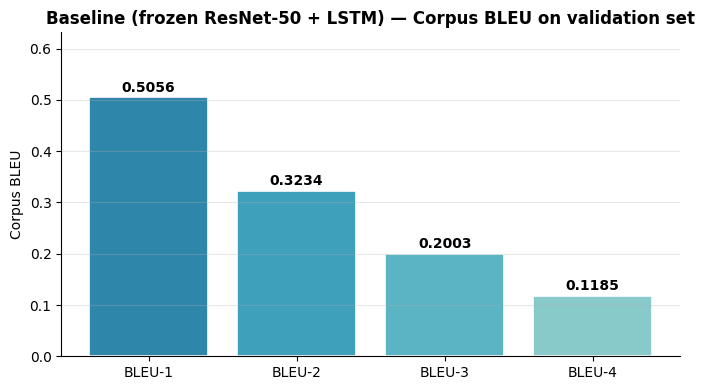

In [13]:
# @title **BLEU Bar Chart**
fig, ax = plt.subplots(figsize=(7, 4))
names  = list(scores.keys())
values = list(scores.values())
colors = ['#2E86AB', '#3FA0BC', '#5BB4C3', '#88C9C9']
bars = ax.bar(names, values, color=colors, edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Corpus BLEU')
ax.set_title('Baseline (frozen ResNet-50 + LSTM) — Corpus BLEU on validation set', fontweight='bold')
ax.set_ylim(0, max(values) * 1.25)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### **8.2 Per-Image BLEU Distribution**

**Methodology**: the corpus BLEU is a single average. Four histograms (one per BLEU-N) reveal whether the model is uniformly mediocre, bimodally good-or-bad, or otherwise distributed. Mean and median markers are overlaid. This view is essential for an honest *Limitations* discussion.

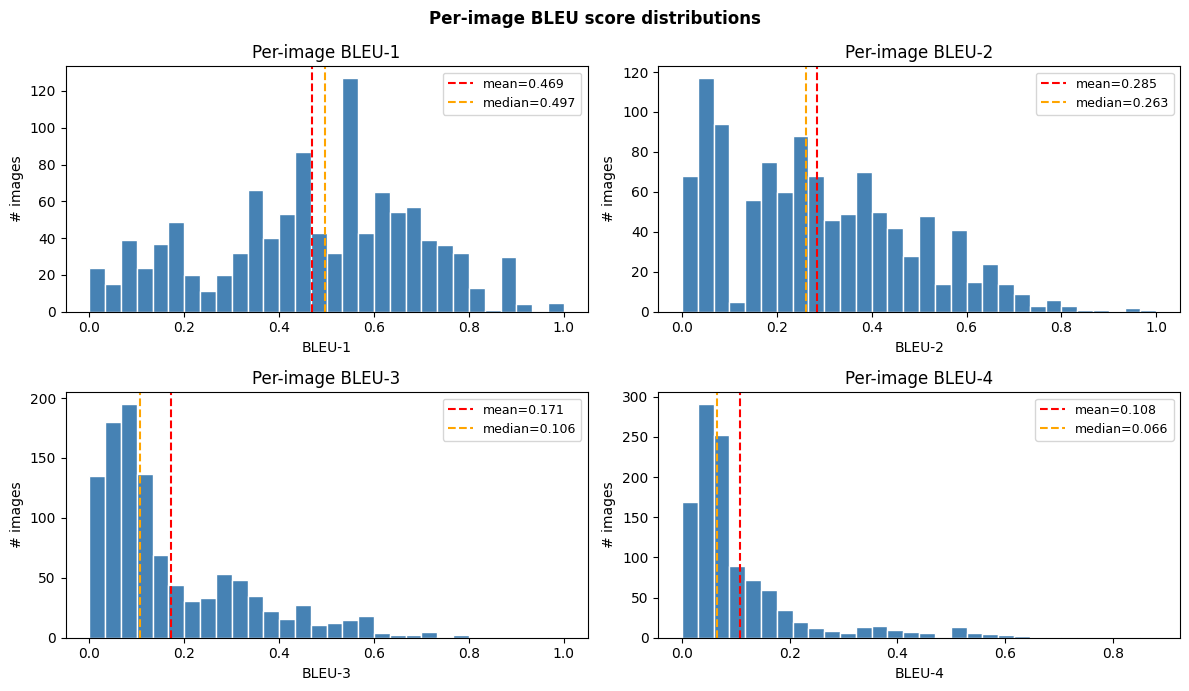


Per-image BLEU statistics:
           bleu1      bleu2      bleu3      bleu4
count  1098.0000  1098.0000  1098.0000  1098.0000
mean      0.4692     0.2853     0.1713     0.1075
std       0.2193     0.1972     0.1602     0.1188
min       0.0000     0.0000     0.0000     0.0000
25%       0.3333     0.0960     0.0525     0.0377
50%       0.4971     0.2626     0.1060     0.0657
75%       0.6250     0.4085     0.2648     0.1293
max       1.0000     1.0000     1.0000     0.8801


In [14]:
# @title **Per-Image BLEU Distribution**
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, n in zip(axes.ravel(), [1, 2, 3, 4]):
    col = f'bleu{n}'
    ax.hist(per_image_df[col], bins=30, color='steelblue', edgecolor='white')
    mean_v = per_image_df[col].mean()
    median_v = per_image_df[col].median()
    ax.axvline(mean_v,   ls='--', color='red',    label=f'mean={mean_v:.3f}')
    ax.axvline(median_v, ls='--', color='orange', label=f'median={median_v:.3f}')
    ax.set_xlabel(f'BLEU-{n}'); ax.set_ylabel('# images')
    ax.set_title(f'Per-image BLEU-{n}')
    ax.legend(loc='upper right', fontsize=9)
fig.suptitle('Per-image BLEU score distributions', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nPer-image BLEU statistics:')
print(per_image_df[['bleu1', 'bleu2', 'bleu3', 'bleu4']].describe().round(4))

### **8.3 Best vs Worst Predictions — Qualitative Inspection**

**Methodology**: the four images with the highest BLEU-1 and the four with the lowest are displayed side-by-side with their predicted and first-reference captions. This is the strongest qualitative evidence for the report's *failure analysis* — both successes and characteristic failure modes are exposed.

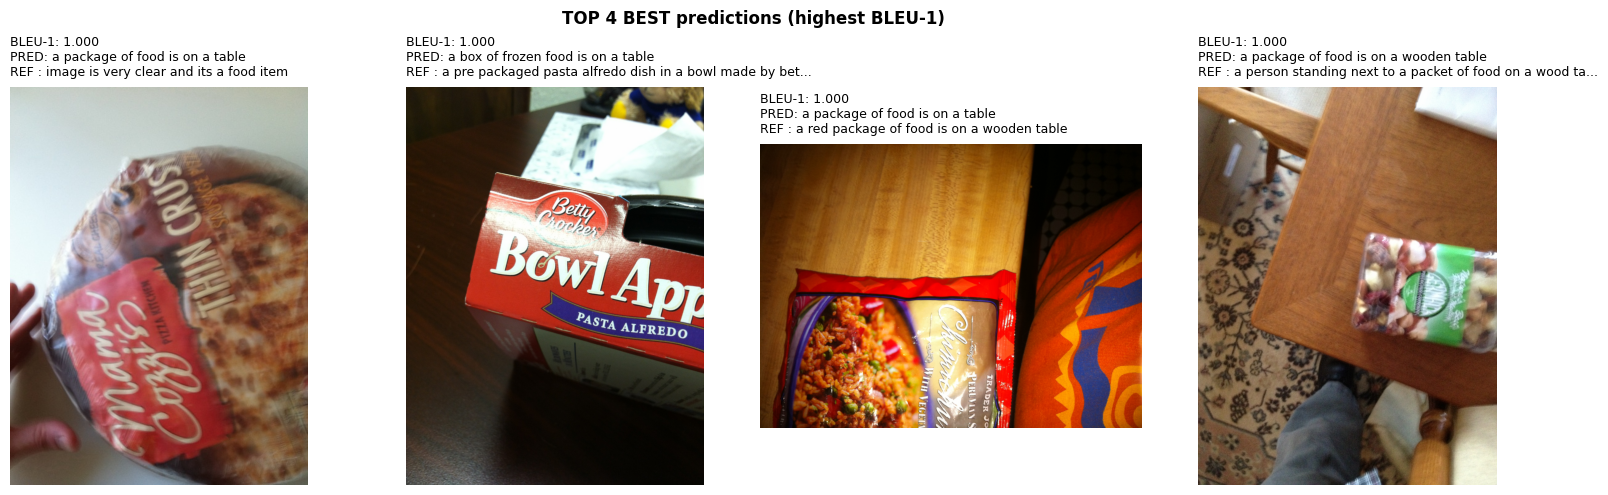

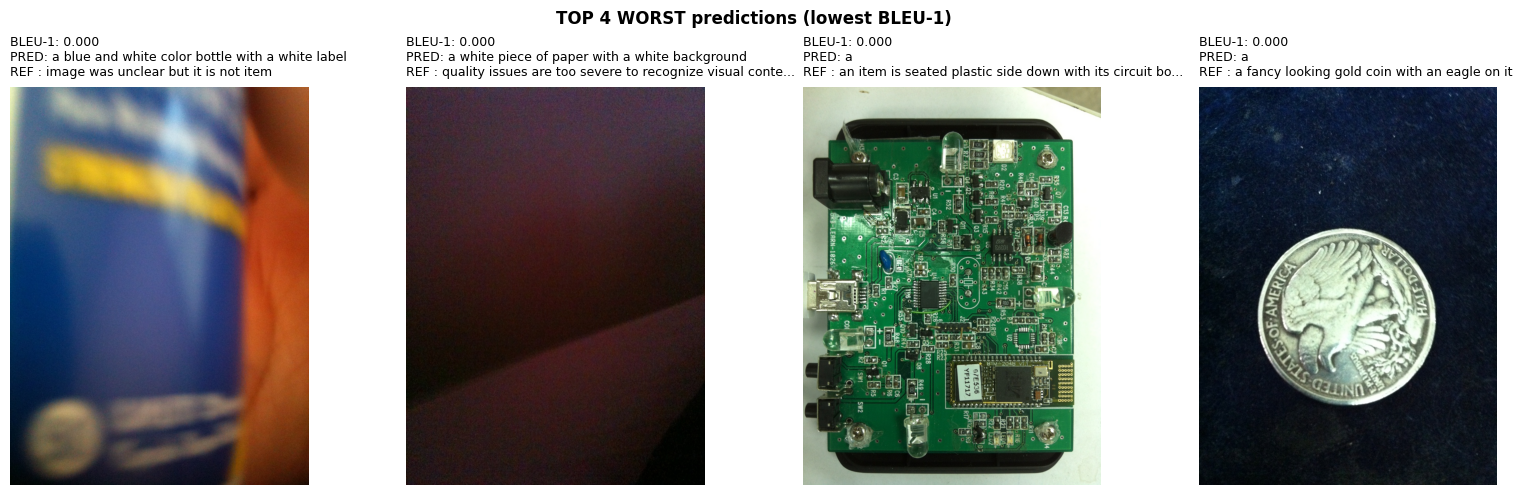

In [15]:
# @title **Best vs Worst Predictions**
TOP_N = 4
best  = per_image_df.nlargest(TOP_N,  'bleu1').reset_index(drop=True)
worst = per_image_df.nsmallest(TOP_N, 'bleu1').reset_index(drop=True)

def show_predictions(df, title):
    fig, axes = plt.subplots(1, TOP_N, figsize=(4 * TOP_N, 5))
    if TOP_N == 1: axes = [axes]
    for ax, (_, row) in zip(axes, df.iterrows()):
        img = Image.open(IMG_DIR / row['filename'])
        ax.imshow(img); ax.axis('off')
        pred = row['hypothesis'][:55] + ('...' if len(row['hypothesis']) > 55 else '')
        ref  = row['reference_1'][:55] + ('...' if len(row['reference_1']) > 55 else '')
        ax.set_title(f'BLEU-1: {row["bleu1"]:.3f}\nPRED: {pred}\nREF : {ref}',
                     fontsize=9, loc='left', pad=8)
    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

show_predictions(best,  f'TOP {TOP_N} BEST predictions (highest BLEU-1)')
show_predictions(worst, f'TOP {TOP_N} WORST predictions (lowest BLEU-1)')

### **8.4 Caption Length Comparison**

**Methodology**: predicted and reference caption length distributions are compared (overlaid histogram + side-by-side boxplot). A model that under-generates (`'a man'`) or over-generates with repetition shows up immediately here.

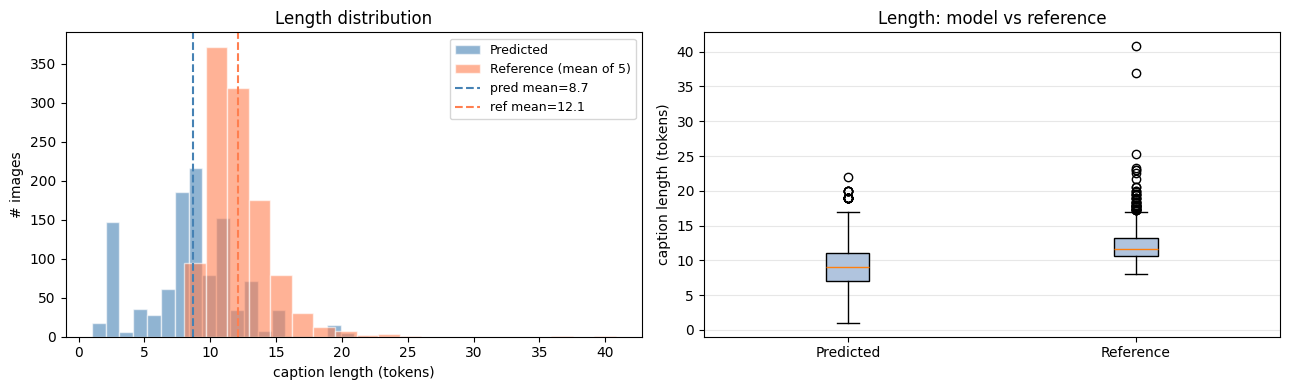

Predicted lengths : mean=8.7  median=9.0  range=[1, 22]
Reference lengths : mean=12.1  median=11.6


In [16]:
# @title **Caption Length Comparison**
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograms overlaid
axes[0].hist(per_image_df['hyp_len'], bins=20, alpha=0.6, label='Predicted',  color='steelblue', edgecolor='white')
axes[0].hist(per_image_df['ref_len'], bins=20, alpha=0.6, label='Reference (mean of 5)', color='coral', edgecolor='white')
axes[0].axvline(per_image_df['hyp_len'].mean(), ls='--', color='steelblue', label=f'pred mean={per_image_df["hyp_len"].mean():.1f}')
axes[0].axvline(per_image_df['ref_len'].mean(), ls='--', color='coral',     label=f'ref mean={per_image_df["ref_len"].mean():.1f}')
axes[0].set_xlabel('caption length (tokens)'); axes[0].set_ylabel('# images')
axes[0].set_title('Length distribution'); axes[0].legend(fontsize=9)

# Box plot side-by-side
axes[1].boxplot([per_image_df['hyp_len'], per_image_df['ref_len']],
                tick_labels=['Predicted', 'Reference'],
                patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue'))
axes[1].set_ylabel('caption length (tokens)')
axes[1].set_title('Length: model vs reference')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

print(f'Predicted lengths : mean={per_image_df["hyp_len"].mean():.1f}  median={per_image_df["hyp_len"].median():.1f}  range=[{per_image_df["hyp_len"].min()}, {per_image_df["hyp_len"].max()}]')
print(f'Reference lengths : mean={per_image_df["ref_len"].mean():.1f}  median={per_image_df["ref_len"].median():.1f}')

### **8.5 Vocabulary Usage and Diversity**

**Methodology**: the top-20 words used by the model and by the references are plotted side-by-side, and a diversity ratio (unique words used / unique words in references) is reported. Mode collapse — the model defaulting to a small set of generic phrases — is the failure mode this view exposes.

Unique words used by MODEL      : 91
Unique words in REFERENCES      : 4,509
Diversity ratio (model / ref)   : 2.02%
Total predicted tokens          : 9,547
Total reference tokens          : 59,901


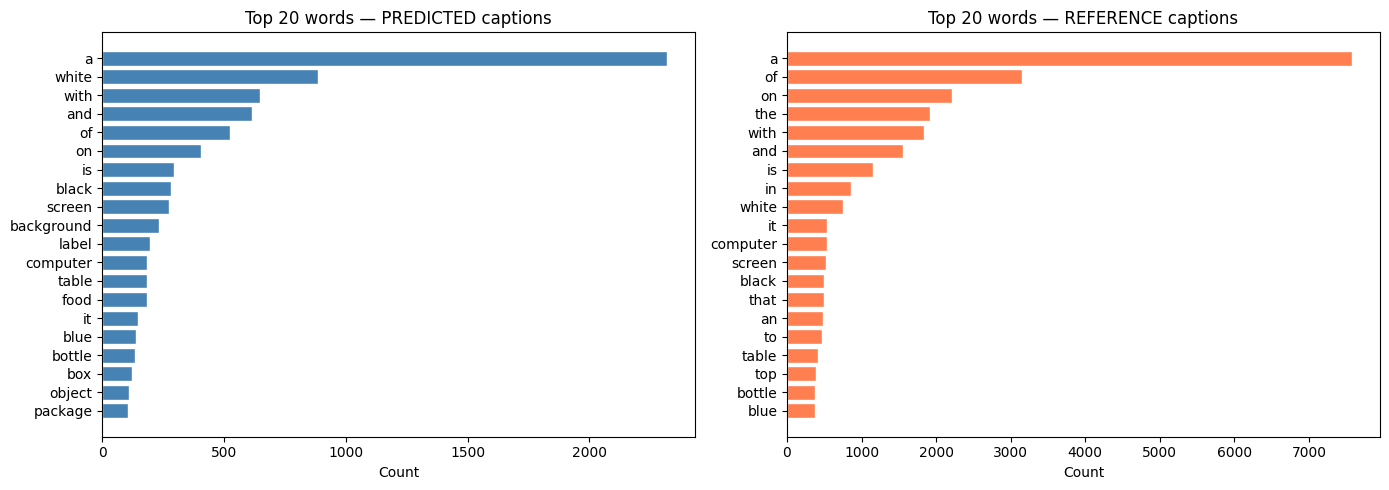

In [17]:
# @title **Vocabulary Usage**
from collections import Counter

hyp_words = Counter(t for h in hyps for t in h)
ref_words = Counter(t for refs_ in refs for r in refs_ for t in r)

print(f'Unique words used by MODEL      : {len(hyp_words):,}')
print(f'Unique words in REFERENCES      : {len(ref_words):,}')
print(f'Diversity ratio (model / ref)   : {len(hyp_words)/max(len(ref_words),1):.2%}')
print(f'Total predicted tokens          : {sum(hyp_words.values()):,}')
print(f'Total reference tokens          : {sum(ref_words.values()):,}')

TOP_N = 20
top_pred = hyp_words.most_common(TOP_N)
top_ref  = ref_words.most_common(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

words, counts = zip(*top_pred)
axes[0].barh(list(reversed(words)), list(reversed(counts)), color='steelblue', edgecolor='white')
axes[0].set_xlabel('Count'); axes[0].set_title(f'Top {TOP_N} words — PREDICTED captions')

words, counts = zip(*top_ref)
axes[1].barh(list(reversed(words)), list(reversed(counts)), color='coral', edgecolor='white')
axes[1].set_xlabel('Count'); axes[1].set_title(f'Top {TOP_N} words — REFERENCE captions')

plt.tight_layout(); plt.show()

### **8.6 Summary Table**

**Methodology**: all metrics (BLEU, length statistics, vocabulary diversity) and training metadata (epochs, trainable parameters, device) are gathered in a single dataframe — ready to drop into the *Results* table of the report.

In [18]:
# @title **Summary Table**
summary = pd.DataFrame([
    ('Corpus BLEU-1',             f'{scores["BLEU-1"]:.4f}'),
    ('Corpus BLEU-2',             f'{scores["BLEU-2"]:.4f}'),
    ('Corpus BLEU-3',             f'{scores["BLEU-3"]:.4f}'),
    ('Corpus BLEU-4',             f'{scores["BLEU-4"]:.4f}'),
    ('Mean per-image BLEU-1',     f'{per_image_df["bleu1"].mean():.4f}'),
    ('Mean per-image BLEU-4',     f'{per_image_df["bleu4"].mean():.4f}'),
    ('Median per-image BLEU-1',   f'{per_image_df["bleu1"].median():.4f}'),
    ('Mean predicted length',     f'{per_image_df["hyp_len"].mean():.1f} tokens'),
    ('Mean reference length',     f'{per_image_df["ref_len"].mean():.1f} tokens'),
    ('Unique words (predicted)',  f'{len(hyp_words):,}'),
    ('Unique words (reference)',  f'{len(ref_words):,}'),
    ('Vocabulary diversity',      f'{len(hyp_words)/max(len(ref_words),1):.2%}'),
    ('# val images evaluated',    f'{len(per_image_df):,}'),
    ('# training epochs',         f'{EPOCHS}'),
    ('Trainable parameters',      f'{n_trainable:,}'),
    ('Device',                    str(device)),
], columns=['Metric', 'Value'])

print(summary.to_string(index=False))

                  Metric       Value
           Corpus BLEU-1      0.5056
           Corpus BLEU-2      0.3234
           Corpus BLEU-3      0.2003
           Corpus BLEU-4      0.1185
   Mean per-image BLEU-1      0.4692
   Mean per-image BLEU-4      0.1075
 Median per-image BLEU-1      0.4971
   Mean predicted length  8.7 tokens
   Mean reference length 12.1 tokens
Unique words (predicted)          91
Unique words (reference)       4,509
    Vocabulary diversity       2.02%
  # val images evaluated       1,098
       # training epochs           5
    Trainable parameters   6,252,824
                  Device         mps


---
**Insights and Recommendations based on BLEU Evaluation**

1. **Corpus BLEU baseline established** — these scores are the threshold each individual Model 1 must beat. Architectural choices (attention, beam search, encoder fine-tuning, deeper decoders) should each justify their added complexity by improving on at least one BLEU-N reported here.
2. **Distribution matters** (8.2) — even if the corpus average looks acceptable, a heavily left-skewed per-image distribution indicates that the model fails outright on many images. Report the median alongside the mean.
3. **Best vs worst** (8.3) — the failure cases reveal whether the model is image-blind (same prediction for everything → mode collapse) or scene-confused (specific but wrong descriptions). The improvement strategy is different for each.
4. **Caption length** (8.4) — a systematic under-generation or repetition pattern should motivate decoder design choices (beam search, length penalty, repetition penalty).
5. **Vocabulary diversity** (8.5) — a model using only 10-20% of the reference vocabulary is suffering from mode collapse and will not generalise.


---
# **9. Summary, Limitations & Next Steps**
---


**Summary of what this notebook achieves**

- A working end-to-end image-captioning pipeline: data loading → frozen pretrained encoder → trainable decoder → training with teacher forcing → greedy inference → BLEU evaluation.
- Quantitative results: corpus BLEU-1 through BLEU-4 plus per-image distributions.
- Qualitative results: sample generations, best/worst comparisons, vocabulary usage.

**Limitations of the baseline**

| Limitation | Impact | Improvement direction |
|---|---|---|
| No attention mechanism | Decoder sees the image once at t=0, then forgets | Add Bahdanau or Luong attention (Show, Attend & Tell) |
| Encoder fully frozen | Cannot adapt visual features to VizWiz characteristics (blur, low light, occlusions) | Unfreeze the last ResNet block after the decoder has stabilised |
| Greedy decoding | Often emits generic, high-frequency tokens | Beam search (beam=5) typically gives +1-2 BLEU-4 |
| Single LSTM layer | Limited capacity for long-range structure | Two-layer LSTM with inter-layer dropout |
| Only 5 training epochs | Underfit | 15-30 epochs with learning-rate scheduling |
| One random caption per image per epoch | Effectively 1/5 the training signal | Expand each image into 5 separate training examples |

**Recommendations for individual Model 1 architectures**

Each group member should pick a distinct combination from the design space:

1. CNN encoder family (ResNet-18/50/101, Inception, VGG, EfficientNet)
2. Decoder type (LSTM, GRU, Transformer)
3. Attention mechanism (none, additive, multiplicative)
4. Encoder fine-tuning (frozen, last-block fine-tuned, fully fine-tuned)
5. Decoding strategy (greedy, beam search, nucleus sampling)

This baseline serves as the *common reference point* against which each individual model's improvements are measured.
